In [1]:
# Portions of this code were writen with the assistance of AI tools (Gemini)

import pandas as pd
import ast

# Load the aggregated file
fh = "02"
agg_df = pd.read_csv(f"/home/csutter/DRIVE-clean/forecasting/data_HT_aggregate/FH{fh}/Aggregated_HT_FH{fh}.csv")
print(len(agg_df))

# Make sure all models were ran for all 30 splits
agg_df = agg_df[agg_df['trackers_completed'] == 30]
print(len(agg_df)) # should be same number as above


print("number of algorithms & hyps considered")
print(len(agg_df))

330
330
number of algorithms & hyps considered
330


In [2]:
TOP_N = 5 # Adjust this threshold

# Take the top N models by Average Recall
top_candidates = agg_df.nlargest(TOP_N, 'avg_recall')
# print("top candidates")
# display(top_candidates)

# From that subset, find the single model with the highest Total Accuracy
best_model = top_candidates.loc[top_candidates['total_acc'].idxmax()]

print("=== SELECTED BEST ARCHITECTURE ===")
print(f"Algorithm: {best_model['algorithm']}")
print(f"Average Recall: {best_model['avg_recall']:.4f}")
print(f"Total Accuracy: {best_model['total_acc']:.4f}")
print("Hyperparameters:")

# Print hyperparameters cleanly
hyps = ast.literal_eval(best_model['hyperparameters'])
for k, v in hyps.items():
    print(f"  {k}: {v}")

=== SELECTED BEST ARCHITECTURE ===
Algorithm: RandomForest
Average Recall: 0.7460
Total Accuracy: 0.7654
Hyperparameters:
  max_depth: 10
  max_samples: 0.5
  n_estimators: 300
  max_features: 2
  min_samples_leaf: 5
  bootstrap: True


In [3]:
# USING: TOP_N = 5 # Adjust this threshold

# SELECTED MODEL: FH02

# === SELECTED BEST ARCHITECTURE ===
# Algorithm: RandomForest
# Average Recall: 0.7460
# Total Accuracy: 0.7654
# Hyperparameters:
#   max_depth: 10
#   max_samples: 0.5
#   n_estimators: 300
#   max_features: 2
#   min_samples_leaf: 5
#   bootstrap: True


# SELECTED MODEL: FH09

# === SELECTED BEST ARCHITECTURE ===
# Algorithm: RandomForest
# Average Recall: 0.7247
# Total Accuracy: 0.7605
# Hyperparameters:
#   max_depth: 10
#   max_samples: 0.5
#   n_estimators: 100
#   max_features: 2
#   min_samples_leaf: 5
#   bootstrap: True


# SELECTED MODEL: FH24

# === SELECTED BEST ARCHITECTURE ===
# Algorithm: RandomForest
# Average Recall: 0.7296
# Total Accuracy: 0.7621
# Hyperparameters:
#   max_depth: None
#   max_samples: 0.5
#   n_estimators: 100
#   max_features: 2
#   min_samples_leaf: 5
#   bootstrap: True

# Plots for dissertation

In [4]:
WINNING_MODELS = {
    "modelFH02": {"algorithm": "RandomForest", "hyps": {"max_depth": 10, "max_samples": 0.5, "n_estimators": 300, "max_features": 2, "min_samples_leaf": 5, "bootstrap": True}},
    "modelFH09": {"algorithm": "RandomForest", "hyps": {"max_depth": 10, "max_samples": 0.5, "n_estimators": 100, "max_features": 2, "min_samples_leaf": 5, "bootstrap": True}},
    "modelFH24": {"algorithm": "RandomForest", "hyps": {"max_depth": None, "max_samples": 0.5, "n_estimators": 100, "max_features": 2, "min_samples_leaf": 5, "bootstrap": True}}
}

=== BEST HYPERPARAMETERS PER ALGORITHM (Plotting: Average Recall) ===

RANDOMFOREST:
  Avg Recall: 0.7460 | Total Acc: 0.7654
    max_depth: 10
    max_samples: 0.5
    n_estimators: 300
    max_features: 2
    min_samples_leaf: 5
    bootstrap: True

SVM:
  Avg Recall: 0.7260 | Total Acc: 0.7284
    kernel: rbf
    C: 1
    gamma: 1

DNN:
  Avg Recall: 0.7064 | Total Acc: 0.6880
    hidden_layers: 3
    hidden_units: [64, 32, 16]
    dropout: 0.0
    l2_reg: 0.0

LOGISTICREGRESSION:
  Avg Recall: 0.5402 | Total Acc: 0.7151
    max_iter: 300
    C: 10.0

GAUSSIANNB:
  Avg Recall: 0.4919 | Total Acc: 0.6074
    var_smoothing: 1e-06


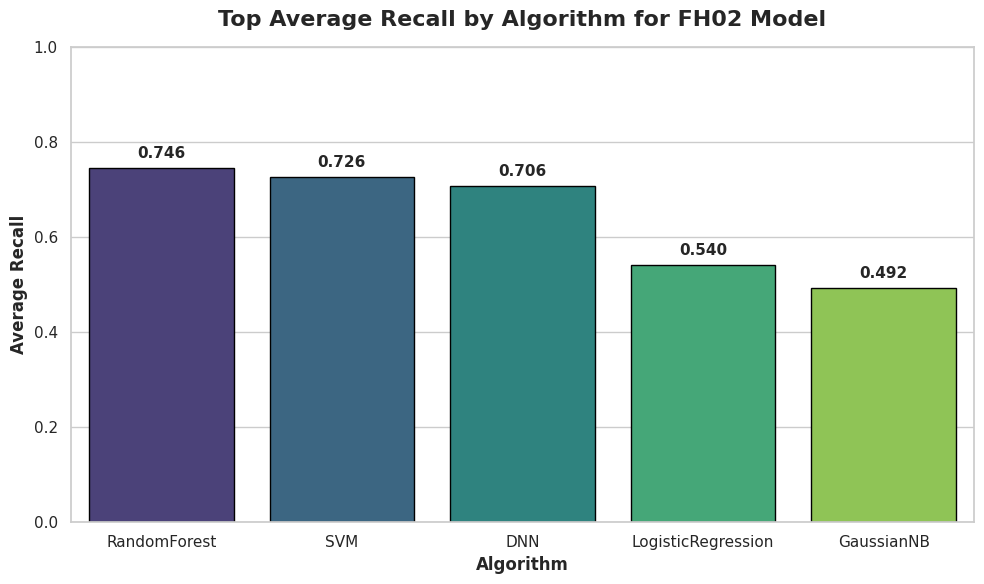

=== BEST HYPERPARAMETERS PER ALGORITHM (Plotting: Accuracy) ===

RANDOMFOREST:
  Avg Recall: 0.7460 | Total Acc: 0.7654
    max_depth: 10
    max_samples: 0.5
    n_estimators: 300
    max_features: 2
    min_samples_leaf: 5
    bootstrap: True

SVM:
  Avg Recall: 0.7260 | Total Acc: 0.7284
    kernel: rbf
    C: 1
    gamma: 1

DNN:
  Avg Recall: 0.7064 | Total Acc: 0.6880
    hidden_layers: 3
    hidden_units: [64, 32, 16]
    dropout: 0.0
    l2_reg: 0.0

LOGISTICREGRESSION:
  Avg Recall: 0.5402 | Total Acc: 0.7151
    max_iter: 300
    C: 10.0

GAUSSIANNB:
  Avg Recall: 0.4919 | Total Acc: 0.6074
    var_smoothing: 1e-06


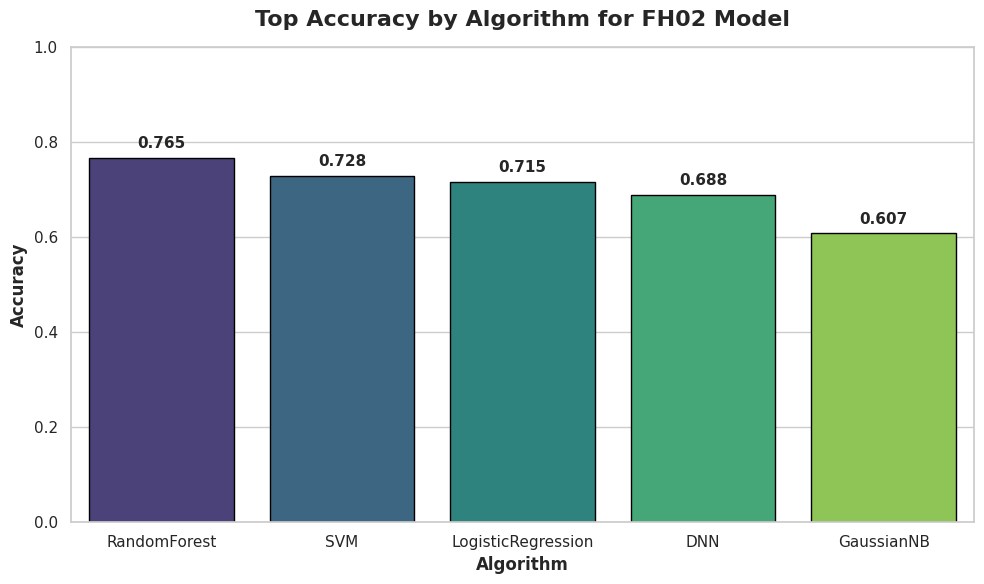

In [16]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. FIND THE BEST MODEL PER ALGORITHM (USING TWO-STEP LOGIC)
# ==========================================
fh = "02"
dfread = pd.read_csv(f"/home/csutter/DRIVE-clean/forecasting/data_HT_aggregate/FH{fh}/Aggregated_HT_FH{fh}.csv")

def makebarplot(metric_to_plot, metrictitle, agg_df = dfread):
    # Ensure complete runs
    agg_df = agg_df[agg_df['trackers_completed'] == 30]

    TOP_N = 5
    best_models_list = []

    # Apply your exact two-step logic to EACH algorithm independently
    for alg in agg_df['algorithm'].unique():
        alg_df = agg_df[agg_df['algorithm'] == alg]
        
        # Step 1: ALWAYS take the top N models by Average Recall (HARDCODED)
        top_candidates = alg_df.nlargest(TOP_N, 'avg_recall')
        
        # Step 2: ALWAYS tie-break with highest Total Accuracy (HARDCODED)
        best_model = top_candidates.loc[top_candidates['total_acc'].idxmax()]
        
        best_models_list.append(best_model)

    # Recombine the selected winners into a single DataFrame
    best_per_alg = pd.DataFrame(best_models_list)

    print(f"=== BEST HYPERPARAMETERS PER ALGORITHM (Plotting: {metrictitle}) ===")
    for index, row in best_per_alg.iterrows():
        print(f"\n{row['algorithm'].upper()}:")
        print(f"  Avg Recall: {row['avg_recall']:.4f} | Total Acc: {row['total_acc']:.4f}")
        
        hyps = ast.literal_eval(row['hyperparameters'])
        for k, v in hyps.items():
            print(f"    {k}: {v}")

    # ==========================================
    # 2. VISUALIZE PERFORMANCE ACROSS ALGORITHMS
    # ==========================================
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Plotting the results using the specific metric for the y-axis
    ax = sns.barplot(
        data=best_per_alg.sort_values(metric_to_plot, ascending=False), 
        x='algorithm', 
        y=metric_to_plot, 
        palette='viridis',
        edgecolor='black'
    )

    plt.title(f'Top {metrictitle} by Algorithm for FH{fh} Model', pad=15, fontsize=16, fontweight='bold')
    plt.xlabel('Algorithm', fontweight='bold', fontsize=12)
    plt.ylabel(metrictitle, fontweight='bold', fontsize=12)

    # Add the scores directly on top of the bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), 
                    textcoords='offset points')

    plt.ylim(0, 1.0) 
    plt.tight_layout()
    plt.show()

# Execution remains exactly the same:
makebarplot(metric_to_plot = 'avg_recall', metrictitle = 'Average Recall')
makebarplot(metric_to_plot = 'total_acc', metrictitle = 'Accuracy')

In [17]:
import pandas as pd
import numpy as np
import scipy.stats as st

# =========================================
# CONFIGURATION
# =========================================
fh = "02"
# 1. The raw tracker results (where the 30 individual folds live)
raw_csv = f"/home/csutter/DRIVE-clean/forecasting/data_HT_results/FH{fh}/HT_results_FH{fh}.csv"

# 2. The aggregated results (where we easily find the winners)
agg_csv = f"/home/csutter/DRIVE-clean/forecasting/data_HT_aggregate/FH{fh}/Aggregated_HT_FH{fh}.csv"

print("Loading data...")
raw_df = pd.read_csv(raw_csv, on_bad_lines='skip')
agg_df = pd.read_csv(agg_csv)

# Ensure the raw dataframe has the total_acc calculated per fold
raw_df['total_acc'] = np.where(raw_df['n_labeled_total'] > 0, 
                               raw_df['n_correct_total'] / raw_df['n_labeled_total'], 0.0)

# ==========================================
# FIND THE BEST MODEL PER ALGORITHM
# ==========================================
agg_df = agg_df[agg_df['trackers_completed'] == 30]
TOP_N = 5
best_models_list = []

for alg in agg_df['algorithm'].unique():
    alg_df = agg_df[agg_df['algorithm'] == alg]
    top_candidates = alg_df.nlargest(TOP_N, 'avg_recall')
    best_model = top_candidates.loc[top_candidates['total_acc'].idxmax()]
    best_models_list.append(best_model)

best_per_alg = pd.DataFrame(best_models_list)

# ==========================================
# CALCULATE VARIANCES FOR LATEX TABLE
# ==========================================
print("\n=== LATEX TABLE STATISTICS (Across 30 Folds) ===")

for index, row in best_per_alg.iterrows():
    alg = row['algorithm']
    best_hyp_str = row['hyperparameters']
    
    # Isolate the 30 raw folds for this exact algorithm + hyperparameter combo
    winning_folds = raw_df[(raw_df['algorithm'] == alg) & (raw_df['hyperparameters'] == best_hyp_str)]
    
    if len(winning_folds) != 30:
        print(f"Warning: Expected 30 folds for {alg}, but found {len(winning_folds)}. Check your raw data!")
        continue
        
    # Grab the 30 accuracy percentages
    accuracies = winning_folds['total_acc'].values
    
    # Calculate Statistics
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies, ddof=1) # Sample standard deviation
    
    # 95% Confidence Interval using t-distribution
    ci = st.t.interval(0.95, df=len(accuracies)-1, loc=mean_acc, scale=st.sem(accuracies))
    
    print(f"\n{alg.upper()}:")
    print(f"  LaTeX String: \\hbox{{Acc: {mean_acc * 100:.1f}\\%}} \\hbox{{Std: {std_acc * 100:.1f}\\%}} \\hbox{{CI: ({ci[0] * 100:.1f}\\%, {ci[1] * 100:.1f}\\%)}}")

Loading data...

=== LATEX TABLE STATISTICS (Across 30 Folds) ===

RANDOMFOREST:
  LaTeX String: \hbox{Acc: 76.6\%} \hbox{Std: 2.8\%} \hbox{CI: (75.5\%, 77.6\%)}

SVM:
  LaTeX String: \hbox{Acc: 72.9\%} \hbox{Std: 3.3\%} \hbox{CI: (71.7\%, 74.1\%)}

DNN:
  LaTeX String: \hbox{Acc: 68.9\%} \hbox{Std: 4.4\%} \hbox{CI: (67.2\%, 70.5\%)}

LOGISTICREGRESSION:
  LaTeX String: \hbox{Acc: 71.6\%} \hbox{Std: 2.3\%} \hbox{CI: (70.7\%, 72.4\%)}

GAUSSIANNB:
  LaTeX String: \hbox{Acc: 60.8\%} \hbox{Std: 4.7\%} \hbox{CI: (59.1\%, 62.6\%)}
